# Traffic bursts: organic, self-generated, or a crawler?

Daily pageviews aren't flat — some days are 5-10x the usual rate. This notebook asks *why*,
using signals the live beacon never recorded (it only ever stored `{hits, pages}` — no
browser, referrer, session or geography, by design). Those signals only exist for the
pre-migration era, in the full Umami export (Jan 1 – Aug 10, 2026). **A burst in the
beacon-only era after that date is invisible to this kind of analysis** unless the schema
changes — noted here as a real limit, not something this notebook works around.

The approach: flag statistically unusual days, then for each one compute five signals that,
together, distinguish a crawl from a crowd from a single recurring visitor — rather than
reading raw CSV rows by hand.

In [1]:
import re
from collections import Counter
from pathlib import Path

import pandas as pd

CSV_PATH = "export/website_event.csv"
BLOG_DIR = Path("../../website/blog")
SITE_HOSTNAME = "www.fretchen.eu"
PAGEVIEW = "1"  # Umami event_type: 1 = pageview, 2 = custom event

df = pd.read_csv(CSV_PATH, dtype=str, keep_default_na=False)
pv = df[(df["event_type"] == PAGEVIEW) & (df["hostname"] == SITE_HOSTNAME)].copy()
pv["day"] = pv["created_at"].str[:10]
pv["hour"] = pv["created_at"].str[11:13].astype(int)

span = f"{pv['day'].min()} .. {pv['day'].max()}"
print(f"{len(pv)} pageviews, {span}, {pv['day'].nunique()} distinct days")

1612 pageviews, 2026-01-01 .. 2026-08-10, 214 distinct days


## 1. Burst detection

Flags days above `median + 3 × MAD` (median absolute deviation) — a robust outlier rule:
unlike mean + stdev, a handful of huge spikes can't drag the baseline itself upward and hide
smaller bursts. `k=3` was chosen by checking it against three days already inspected by hand
(2026-08-08, 2026-03-26, 2026-03-15) — all three clear it, and the resulting set (23 days)
is short enough to read in full rather than a list so long it stops being useful.

In [2]:
daily = pv.groupby("day").size().rename("pageviews").sort_index()

median = daily.median()
mad = (daily - median).abs().median()
K = 3
threshold = median + K * mad

bursts = daily[daily > threshold].sort_index()

print(f"baseline: median {median:.0f}/day, MAD {mad:.0f} -> threshold {threshold:.0f}")
print(f"{len(bursts)} burst days out of {len(daily)}:\n")
print(bursts.to_string())

baseline: median 5/day, MAD 3 -> threshold 14
23 burst days out of 214:

day
2026-01-13    26
2026-01-25    26
2026-02-05    47
2026-02-08    35
2026-03-15    26
2026-03-21    23
2026-03-23    19
2026-03-24    18
2026-03-26    38
2026-04-16    22
2026-04-20    24
2026-04-24    22
2026-04-26    19
2026-05-05    16
2026-05-13    30
2026-05-14    15
2026-05-25    32
2026-06-03    21
2026-06-06    21
2026-06-15    17
2026-07-14    20
2026-08-08    56
2026-08-09    39


## 2. Blog publish dates

Mirrors the two fields `website/utils/blogLoader.ts` reads from frontmatter at build time —
reimplemented here rather than imported, since this is Python. Posts without a `tokenID`
aren't reachable at `/blog/{id}/` at all, so they're skipped rather than forced in.

In [3]:
FRONTMATTER = re.compile(r"^---\n(.*?)\n---", re.DOTALL)
TOKEN_ID = re.compile(r"^tokenID:\s*(\S+)", re.MULTILINE)
PUBLISH_DATE = re.compile(r"^publishing_date:\s*[\"']?(\d{4}-\d{2}-\d{2})[\"']?", re.MULTILINE)


def load_publish_dates(blog_dir: Path) -> dict[str, str]:
    """tokenID (as it appears in /blog/{id}/) -> publishing_date, for posts that have both."""
    dates: dict[str, str] = {}
    for path in sorted(blog_dir.glob("*.mdx")) + sorted(blog_dir.glob("*.md")):
        match = FRONTMATTER.match(path.read_text())
        if not match:
            continue
        frontmatter = match.group(1)
        token_id = TOKEN_ID.search(frontmatter)
        publish_date = PUBLISH_DATE.search(frontmatter)
        if token_id and publish_date:
            dates[token_id.group(1)] = publish_date.group(1)
    return dates


publish_dates = load_publish_dates(BLOG_DIR)
print(f"{len(publish_dates)} posts with a tokenID and a publishing_date")

18 posts with a tokenID and a publishing_date


## 3. Per-burst diagnostics

Five signals, read together rather than any one alone:

- **session ratio** (distinct sessions ÷ pageviews) — near 1.0 means every view is a new
  session with no repeat pages (bot-shaped); well below 1.0 means people browsing multiple
  pages in one visit.
- **top fingerprint share** — the largest `(browser, os, device)` combination's share of the
  day. One combination dominating means a single actor, whichever kind; several with no
  majority means many distinct real visitors.
- **direct/no-referrer share** — high on its own is ambiguous (could be a dark-social share
  or a bot), which is exactly why it's read alongside the other four, never alone.
- **top page share**, and whether that page is a `/blog/{id}/` post — if so, how many days
  separate the burst from that post's `publishing_date` (0-3 days is a real "the post did
  this" candidate; months apart is not).
- **hour spread** — the number of distinct UTC hours with at least one hit, out of 24. Tight
  clustering (a handful of hours) points at a single session or a short-lived campaign;
  spread across nearly all 24 suggests either a slow crawl or genuinely global organic reach.

In [4]:
BLOG_PATH = re.compile(r"^/(?:[a-z]{2}/)?blog/(\d+)/?$")


def diagnose(day: str) -> dict:
    rows = pv[pv["day"] == day]
    n = len(rows)

    fingerprints = Counter(zip(rows["browser"], rows["os"], rows["device"]))
    top_fp, top_fp_count = fingerprints.most_common(1)[0]

    referrers = Counter(d if d else "(direct/none)" for d in rows["referrer_domain"])
    direct_count = referrers.get("(direct/none)", 0)

    paths = Counter(rows["url_path"])
    top_path, top_path_count = paths.most_common(1)[0]

    blog_match = BLOG_PATH.match(top_path)
    days_since_publish = None
    if blog_match and blog_match.group(1) in publish_dates:
        published = pd.Timestamp(publish_dates[blog_match.group(1)])
        days_since_publish = (pd.Timestamp(day) - published).days

    return {
        "day": day,
        "pageviews": n,
        "sessions": rows["session_id"].nunique(),
        "session_ratio": round(rows["session_id"].nunique() / n, 2),
        "top_fingerprint": top_fp,
        "top_fp_share": round(top_fp_count / n, 2),
        "direct_share": round(direct_count / n, 2),
        "top_referrers": referrers.most_common(3),
        "countries": Counter(rows["country"]).most_common(5),
        "top_path": top_path,
        "top_path_share": round(top_path_count / n, 2),
        "days_since_publish": days_since_publish,
        "distinct_hours": rows["hour"].nunique(),
    }


diagnostics = [diagnose(day) for day in bursts.index]

## 4. A heuristic hint, not a verdict

One line per burst, built from the numbers directly above it — meant to save re-deriving the
same comparison by hand each time, not to replace your own read of the underlying table.

In [5]:
def hint(d: dict) -> str:
    if d["session_ratio"] >= 0.9 and d["top_fp_share"] >= 0.7 and d["direct_share"] >= 0.8:
        return "looks like a crawl (one fingerprint, one-shot sessions, no referrers)"
    if d["top_fp_share"] >= 0.7 and d["session_ratio"] < 0.7:
        return "looks like a single visitor browsing repeatedly (maybe you)"
    if d["session_ratio"] < 0.8 and d["top_fp_share"] < 0.5:
        note = ""
        if d["days_since_publish"] is not None and 0 <= d["days_since_publish"] <= 3:
            note = f" — {d['days_since_publish']}d after {d['top_path']} published"
        return "looks organic (diverse visitors, real browsing)" + note
    return "ambiguous — read the table below"


for d in diagnostics:
    print(f"{d['day']}  ({d['pageviews']:>3} views)  {hint(d)}")
    print(
        f"    sessions={d['sessions']}/{d['pageviews']} (ratio {d['session_ratio']})"
        f"  top_fingerprint={d['top_fingerprint']} ({d['top_fp_share']:.0%})"
        f"  direct={d['direct_share']:.0%}"
    )
    print(
        f"    top_path={d['top_path']} ({d['top_path_share']:.0%})"
        + (
            f", published {d['days_since_publish']}d earlier"
            if d["days_since_publish"] is not None
            else ""
        )
    )
    print(f"    countries={d['countries']}")
    print(f"    hours_active={d['distinct_hours']}/24")
    print()

2026-01-13  ( 26 views)  ambiguous — read the table below
    sessions=4/26 (ratio 0.15)  top_fingerprint=('chrome', 'Mac OS', 'laptop') (62%)  direct=77%
    top_path=/ (77%)
    countries=[('US', 18), ('LT', 7), ('ES', 1)]
    hours_active=1/24

2026-01-25  ( 26 views)  ambiguous — read the table below
    sessions=11/26 (ratio 0.42)  top_fingerprint=('chrome', 'Mac OS', 'laptop') (65%)  direct=77%
    top_path=/ (69%)
    countries=[('US', 15), ('GB', 8), ('SG', 2), ('DE', 1)]
    hours_active=5/24

2026-02-05  ( 47 views)  ambiguous — read the table below
    sessions=16/47 (ratio 0.34)  top_fingerprint=('chrome', 'Mac OS', 'laptop') (57%)  direct=77%
    top_path=/ (66%)
    countries=[('US', 26), ('FR', 8), ('RO', 5), ('SG', 4), ('DE', 4)]
    hours_active=6/24

2026-02-08  ( 35 views)  ambiguous — read the table below
    sessions=12/35 (ratio 0.34)  top_fingerprint=('safari', 'Mac OS', 'laptop') (60%)  direct=71%
    top_path=/ (49%)
    countries=[('DE', 26), ('SG', 3), ('US',

## 5. "Is it me?" — a baseline check, not a lookup

Umami has no owner-identifying field, on purpose — this can't be answered directly. The best
available proxy: a fingerprint that's disproportionate on burst days *and* also shows up as a
small, steady background rate on ordinary (non-burst) days is consistent with one recurring
person, most plausibly you, rather than a crawler that only appears in bursts. This computes
that comparison for each burst's dominant fingerprint; recognizing your own setup in it is
up to you.

In [6]:
quiet_days = daily.index.difference(bursts.index)
quiet = pv[pv["day"].isin(quiet_days)]

for d in diagnostics:
    fp = d["top_fingerprint"]
    quiet_hits = quiet[
        (quiet["browser"] == fp[0]) & (quiet["os"] == fp[1]) & (quiet["device"] == fp[2])
    ]
    quiet_days_seen = quiet_hits["day"].nunique()
    rate = len(quiet_hits) / max(quiet_days_seen, 1)
    print(
        f"{d['day']}: {fp} also appears on {quiet_days_seen}/{len(quiet_days)} quiet days"
        f" ({len(quiet_hits)} hits, {rate:.1f}/day when present)"
    )

2026-01-13: ('chrome', 'Mac OS', 'laptop') also appears on 36/191 quiet days (63 hits, 1.8/day when present)
2026-01-25: ('chrome', 'Mac OS', 'laptop') also appears on 36/191 quiet days (63 hits, 1.8/day when present)
2026-02-05: ('chrome', 'Mac OS', 'laptop') also appears on 36/191 quiet days (63 hits, 1.8/day when present)
2026-02-08: ('safari', 'Mac OS', 'laptop') also appears on 24/191 quiet days (54 hits, 2.2/day when present)
2026-03-15: ('chrome', 'Mac OS', 'laptop') also appears on 36/191 quiet days (63 hits, 1.8/day when present)
2026-03-21: ('chrome', 'Android OS', 'mobile') also appears on 17/191 quiet days (51 hits, 3.0/day when present)
2026-03-23: ('chrome', 'Mac OS', 'laptop') also appears on 36/191 quiet days (63 hits, 1.8/day when present)
2026-03-24: ('chrome', 'Android OS', 'mobile') also appears on 17/191 quiet days (51 hits, 3.0/day when present)
2026-03-26: ('chrome', 'Mac OS', 'laptop') also appears on 36/191 quiet days (63 hits, 1.8/day when present)
2026-04-16:

## 6. The chronic crawler the baseline check missed

Section 5's baseline check has a real gap: it flags a fingerprint as "steady background,
possibly you" using only its presence-rate across quiet days — it never checks whether that
presence is *one* visitor or *many distinct people* who happen to share a common
fingerprint. `chrome/Windows 10/laptop` cleared that check (168/191 quiet days) purely
because Chrome-on-Windows-laptop is the single most common desktop configuration on the
internet — not because it's one recurring device. Checking session and country diversity
immediately rules that out: 709 pageviews, **699 distinct sessions**, 31 countries, 1.01
views/session. That's hundreds of near-strangers sharing a coarse fingerprint, not a person.

Screen resolution is the signal that actually separates them. A `screen` field this coarse
fingerprint doesn't use, but real hardware still constrains it — most people's laptops cluster
around a small set of genuine resolutions, so a **very sharp resolution spike inside an
already-suspicious fingerprint** is worth checking before ruling a fingerprint out.

In [7]:
top_fingerprints = (
    pv.groupby(["browser", "os", "device"])
    .filter(lambda g: len(g) > 50)
    .groupby(["browser", "os", "device"])
)

print(f"{'fingerprint':<32} {'n':>5}  top resolution (share)")
for (browser, os_, device), grp in top_fingerprints:
    counts = grp["screen"].value_counts()
    top_res, top_share = counts.index[0], counts.iloc[0] / len(grp)
    label = f"{browser}/{os_}/{device}"
    print(f"{label:<32} {len(grp):>5}  {top_res} ({top_share:.0%})")

fingerprint                          n  top resolution (share)
chrome/Android OS/mobile            89  375x812 (81%)
chrome/Linux/laptop                207  1920x1080 (55%)
chrome/Mac OS/laptop               224  1920x1080 (48%)
chrome/Windows 10/laptop           709  1280x1200 (80%)
ios/iOS/mobile                     104  480x720 (41%)
safari/Mac OS/laptop               129  1440x900 (71%)


`chrome/Windows 10/laptop` is the only one where a single resolution clears ~75% — the
others top out around 50-70% with genuinely common real-laptop resolutions (1920×1080,
1440×900). `1280×1200` is not a common real Windows-laptop resolution; it's a legacy
aspect ratio more associated with default headless-browser viewports than actual hardware.
Profiling that one slice on its own:

In [8]:
crawler_fp = pv[
    (pv["browser"] == "chrome")
    & (pv["os"] == "Windows 10")
    & (pv["device"] == "laptop")
    & (pv["screen"] == "1280x1200")
]

print(f"{len(crawler_fp)} pageviews ({len(crawler_fp) / len(pv):.1%} of all traffic)")
print(
    f"  distinct sessions: {crawler_fp['session_id'].nunique()} "
    f"({crawler_fp['session_id'].nunique() / len(crawler_fp):.0%} of rows are their own session)"
)
print(f"  no-referrer share: {(crawler_fp['referrer_domain'] == '').mean():.0%}")
print(f"  countries: {crawler_fp['country'].nunique()}")
print(f"  distinct days active: {crawler_fp['day'].nunique()} of {len(daily)} observed")
print(f"  distinct pages touched: {crawler_fp['url_path'].nunique()}")
print()
print("Top pages it hits — broad, indiscriminate coverage rather than one target:")
print(crawler_fp["url_path"].value_counts().head(10).to_string())

568 pageviews (35.2% of all traffic)
  distinct sessions: 568 (100% of rows are their own session)
  no-referrer share: 100%
  countries: 17
  distinct days active: 179 of 214 observed
  distinct pages touched: 182

Top pages it hits — broad, indiscriminate coverage rather than one target:
url_path
/de/                25
/amo/11             17
/de/quantum/amo/    16
/amo/10             16
/amo/13/            13
/quantum/           13
/quantum/basics/    12
/quantum            11
/de/quantum/amo     11
/blog/15/           11


Every signal from the acute Aug 8-9 spike is here too, just spread thin instead of
concentrated: one-shot sessions (nearly 100%), zero referrers, wide geography, hundreds
of distinct pages touched with no single target. The difference is duration — this one has
been running at a low, steady rate across nearly the entire observed history (179 of ~214
days), which is exactly the shape that fooled section 5's presence-only baseline check.

### Combined crawler share

The acute spike (section 3, `chrome/Linux/laptop`, one-shot no-referrer sessions,
spanning 3+ countries same-day) and this chronic one don't overlap — different `os`
values — so their shares add directly.

In [9]:
session_sizes = pv.groupby("session_id").size()
pv["session_size"] = pv["session_id"].map(session_sizes)

linux_fp = pv[
    (pv["browser"] == "chrome")
    & (pv["os"] == "Linux")
    & (pv["device"] == "laptop")
    & (pv["session_size"] == 1)
    & (pv["referrer_domain"] == "")
]
multi_country_days = linux_fp.groupby("day")["country"].nunique().loc[lambda s: s >= 3].index
acute_spike = linux_fp[linux_fp["day"].isin(multi_country_days)]

combined = len(acute_spike) + len(crawler_fp)
acute_share = len(acute_spike) / len(pv)
crawler_share = len(crawler_fp) / len(pv)
combined_share = combined / len(pv)
print(f"Acute spike (Aug 8-9, multi-country same-day):  {len(acute_spike):>4}  ({acute_share:.1%})")
print(
    f"Chronic crawler (chrome/Win10/1280x1200):       {len(crawler_fp):>4}  ({crawler_share:.1%})"
)
print(f"Combined:                                        {combined:>4}  ({combined_share:.1%})")

Acute spike (Aug 8-9, multi-country same-day):    87  (5.4%)
Chronic crawler (chrome/Win10/1280x1200):        568  (35.2%)
Combined:                                         655  (40.6%)


## Chart

Daily pageviews with burst days marked — a status color (not an arbitrary red), validated
the same way as the last notebook's series colors.

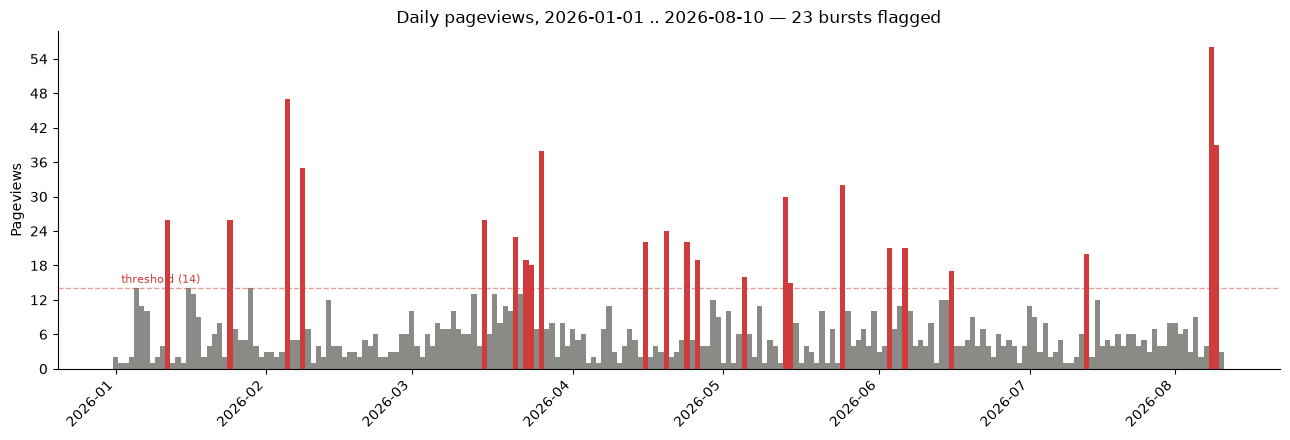

In [10]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

BASE_COLOR = "#8a8a86"  # muted — the ordinary-day baseline is not the story
BURST_COLOR = "#d03b3b"  # fixed status color "critical" — see palette.md, never themed

colors = [BURST_COLOR if day in bursts.index else BASE_COLOR for day in daily.index]

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(range(len(daily)), daily.values, width=1.0, color=colors)

tick_idx = [i for i, day in enumerate(daily.index) if day.endswith("-01")]
ax.set_xticks(tick_idx)
ax.set_xticklabels([daily.index[i][:7] for i in tick_idx], rotation=45, ha="right")
ax.set_ylabel("Pageviews")
ax.set_title(
    f"Daily pageviews, {daily.index.min()} .. {daily.index.max()} — {len(bursts)} bursts flagged"
)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(threshold, color=BURST_COLOR, linewidth=1, linestyle="--", alpha=0.5)
ax.annotate(
    f"threshold ({threshold:.0f})",
    (0, threshold),
    textcoords="offset points",
    xytext=(4, 4),
    fontsize=8,
    color=BURST_COLOR,
)

fig.tight_layout()
plt.show()